# LAB11 - GPS

## Qellimi i laboratorit

Qellimi i ketij laboratori eshte te shohim sa i sakte eshte GPS.

Ne kete laborator perdorim tre matje:

1. Telefoni i palevizur ne nje zone te hapur.
2. Telefoni i palevizur prane nje ndertese.
3. Nje ecje e shkurter rreth 30-50 metra.

GPS nuk eshte perfekt. Edhe kur telefoni nuk leviz, latitude dhe longitude mund te ndryshojne pak.

## Te dhenat

Te dhenat jane marre ne tre raste te ndryshme: zone e hapur, prane nje ndertese dhe gjate ecjes.

Cdo matje permban koordinatat GPS dhe disa te dhena te tjera si saktesia dhe satelitet.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

outdoor = pd.read_csv("data/phone_still.csv")
building = pd.read_csv("data/near_building.csv")
walk = pd.read_csv("data/50_meter_test.csv")

## Kthimi i koordinatave GPS ne metra

Latitude dhe longitude jane ne grade.

Per t'i analizuar me mire, i kthejme ndryshimet e vogla ne metra.

Pozicioni mesatar merret si qendra.

In [2]:
def gps_to_meters(df):
    R = 6371000

    lat = np.deg2rad(df["latitude"].to_numpy())
    lon = np.deg2rad(df["longitude"].to_numpy())

    lat0 = np.mean(lat)
    lon0 = np.mean(lon)

    x = R * np.cos(lat0) * (lon - lon0)
    y = R * (lat - lat0)

    r = np.sqrt(x**2 + y**2)

    return x, y, r

## Statistikat

Ketu llogarisim disa vlera kryesore per GPS.

`r95` tregon rrezen ku ndodhen 95% e pikave GPS.

In [3]:
def gps_statistics(df, name):
    x, y, r = gps_to_meters(df)

    return {
        "Test": name,
        "Numri i matjeve": len(df),
        "Latitude mesatare": df["latitude"].mean(),
        "Longitude mesatare": df["longitude"].mean(),
        "Std x [m]": np.std(x, ddof=1),
        "Std y [m]": np.std(y, ddof=1),
        "Gabimi radial mesatar [m]": np.mean(r),
        "Gabimi radial maksimal [m]": np.max(r),
        "r68 [m]": np.percentile(r, 68),
        "r95 [m]": np.percentile(r, 95),
        "Saktesia horizontale mesatare [m]": df["horizontal_accuracy_m"].mean(),
        "Numri mesatar i sateliteve": df["satellites"].mean()
    }

results = pd.DataFrame([
    gps_statistics(outdoor, "Telefoni palevizur - zone e hapur"),
    gps_statistics(building, "Telefoni palevizur - prane ndertese"),
    gps_statistics(walk, "Ecje 30-50 m")
])

results

,Test,Numri i matjeve,Latitude mesatare,Longitude mesatare,Std x [m],Std y [m],Gabimi radial mesatar [m],Gabimi radial maksimal [m],r68 [m],r95 [m],Saktesia horizontale mesatare [m],Numri mesatar i sateliteve
0,Telefoni palevizur - zone e hapur,300,41.327499,19.818892,2.564892,2.200527,2.922472,10.538524,3.445001,6.022334,6.147033,15.850000
1,Telefoni palevizur - prane ndertese,300,41.329443,19.817402,8.068838,6.543562,8.688765,41.224318,9.567953,17.889290,14.113967,10.233333
2,Ecje 30-50 m,90,41.327656,19.818727,8.931730,10.924604,12.306788,30.903938,16.294661,23.818653,8.076444,13.866667


## Grafiku 2D - telefoni i palevizur

Ky grafik tregon pikat GPS ne metra.

Nese telefoni nuk leviz, pikat duhet te jene afer qendres.

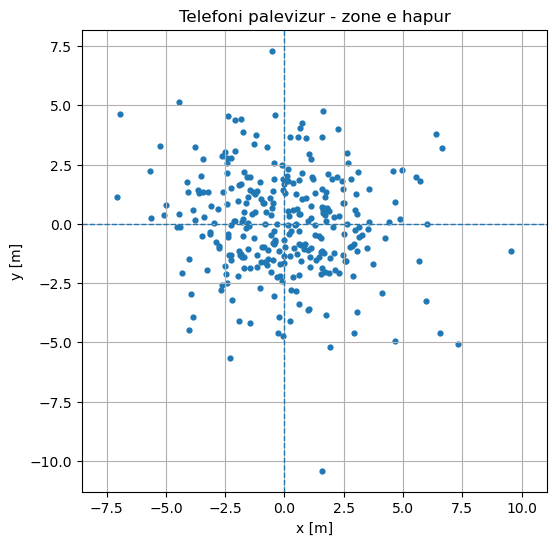

In [4]:
x, y, r = gps_to_meters(outdoor)

plt.figure(figsize=(6, 6))
plt.scatter(x, y, s=12)
plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Telefoni palevizur - zone e hapur")
plt.axis("equal")
plt.grid(True)
plt.show()

## Grafiku 2D - prane ndertese

Ky grafik tregon pikat GPS kur telefoni eshte prane nje ndertese.

Prane nderteses gabimi i GPS mund te jete me i madh.

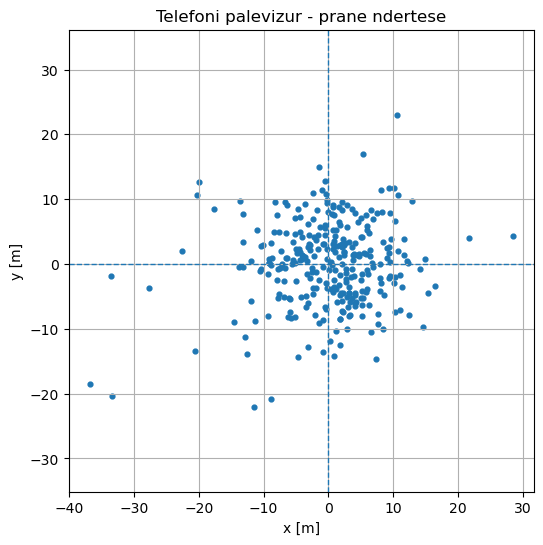

In [5]:
x, y, r = gps_to_meters(building)

plt.figure(figsize=(6, 6))
plt.scatter(x, y, s=12)
plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Telefoni palevizur - prane ndertese")
plt.axis("equal")
plt.grid(True)
plt.show()

## Grafiku 2D - ecja

Ky grafik tregon pikat GPS gjate ecjes.

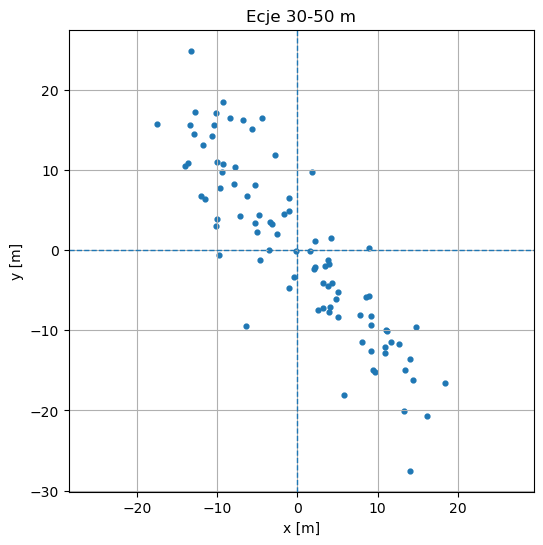

In [6]:
x, y, r = gps_to_meters(walk)

plt.figure(figsize=(6, 6))
plt.scatter(x, y, s=12)
plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Ecje 30-50 m")
plt.axis("equal")
plt.grid(True)
plt.show()

## Histogrami i gabimit radial - telefoni i palevizur

Gabimi radial eshte distanca e cdo pike nga pozicioni mesatar.

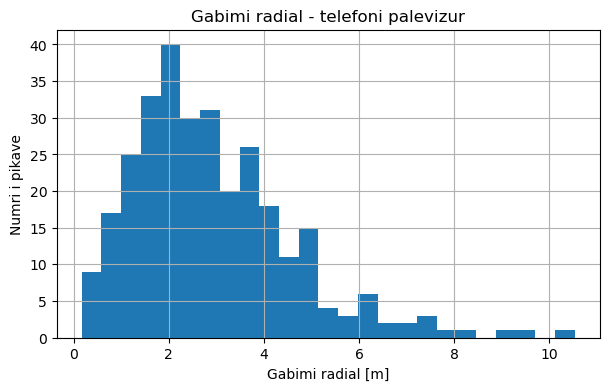

In [7]:
x, y, r = gps_to_meters(outdoor)

plt.figure(figsize=(7, 4))
plt.hist(r, bins=25)
plt.xlabel("Gabimi radial [m]")
plt.ylabel("Numri i pikave")
plt.title("Gabimi radial - telefoni palevizur")
plt.grid(True)
plt.show()

## Histogrami i gabimit radial - prane ndertese

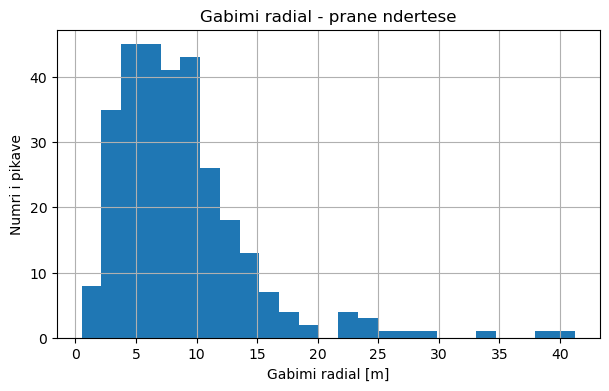

In [8]:
x, y, r = gps_to_meters(building)

plt.figure(figsize=(7, 4))
plt.hist(r, bins=25)
plt.xlabel("Gabimi radial [m]")
plt.ylabel("Numri i pikave")
plt.title("Gabimi radial - prane ndertese")
plt.grid(True)
plt.show()

## Histogrami i gabimit radial - ecja

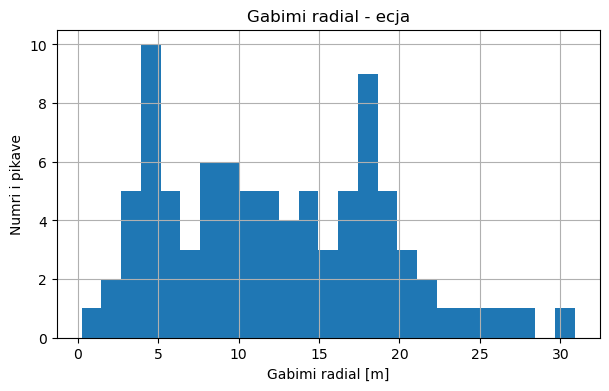

In [9]:
x, y, r = gps_to_meters(walk)

plt.figure(figsize=(7, 4))
plt.hist(r, bins=25)
plt.xlabel("Gabimi radial [m]")
plt.ylabel("Numri i pikave")
plt.title("Gabimi radial - ecja")
plt.grid(True)
plt.show()

## Ndryshimi i pozicionit me kohen

Keta grafike tregojne si ndryshon pozicioni x dhe y me cdo matje.

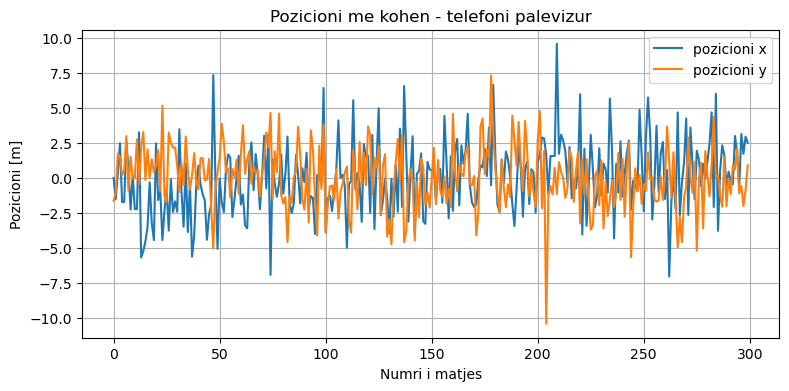

In [10]:
x, y, r = gps_to_meters(outdoor)

plt.figure(figsize=(9, 4))
plt.plot(x, label="pozicioni x")
plt.plot(y, label="pozicioni y")
plt.xlabel("Numri i matjes")
plt.ylabel("Pozicioni [m]")
plt.title("Pozicioni me kohen - telefoni palevizur")
plt.legend()
plt.grid(True)
plt.show()

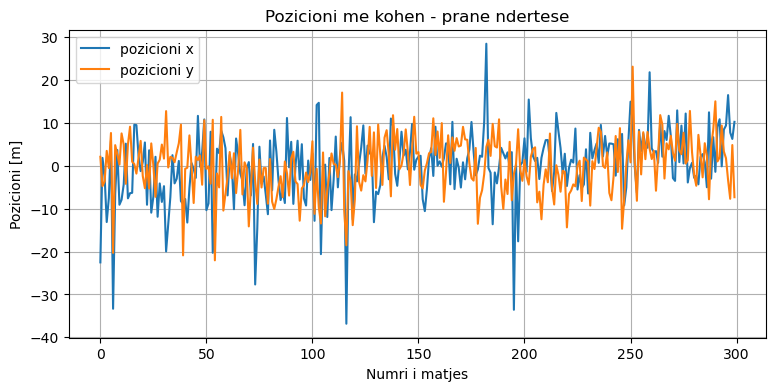

In [11]:
x, y, r = gps_to_meters(building)

plt.figure(figsize=(9, 4))
plt.plot(x, label="pozicioni x")
plt.plot(y, label="pozicioni y")
plt.xlabel("Numri i matjes")
plt.ylabel("Pozicioni [m]")
plt.title("Pozicioni me kohen - prane ndertese")
plt.legend()
plt.grid(True)
plt.show()

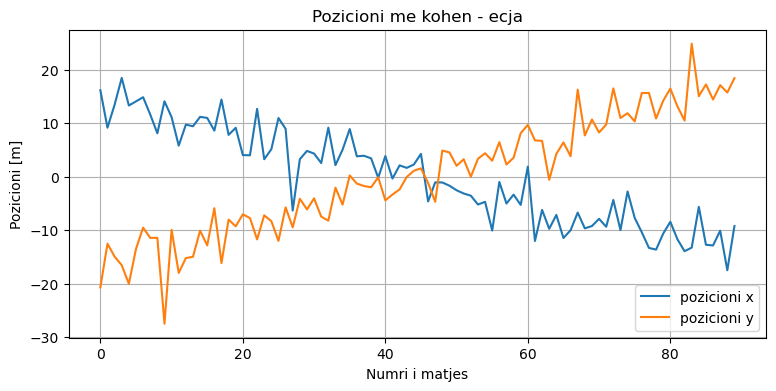

In [12]:
x, y, r = gps_to_meters(walk)

plt.figure(figsize=(9, 4))
plt.plot(x, label="pozicioni x")
plt.plot(y, label="pozicioni y")
plt.xlabel("Numri i matjes")
plt.ylabel("Pozicioni [m]")
plt.title("Pozicioni me kohen - ecja")
plt.legend()
plt.grid(True)
plt.show()

## Krahasimi

Ketu krahasojme zonen e hapur me zonen prane nderteses.

In [13]:
comparison = results[results["Test"].isin([
    "Telefoni palevizur - zone e hapur",
    "Telefoni palevizur - prane ndertese"
])]

comparison[[
    "Test",
    "Std x [m]",
    "Std y [m]",
    "Gabimi radial mesatar [m]",
    "Gabimi radial maksimal [m]",
    "r68 [m]",
    "r95 [m]",
    "Saktesia horizontale mesatare [m]",
    "Numri mesatar i sateliteve"
]]

,Test,Std x [m],Std y [m],Gabimi radial mesatar [m],Gabimi radial maksimal [m],r68 [m],r95 [m],Saktesia horizontale mesatare [m],Numri mesatar i sateliteve
0,Telefoni palevizur - zone e hapur,2.564892,2.200527,2.922472,10.538524,3.445001,6.022334,6.147033,15.850000
1,Telefoni palevizur - prane ndertese,8.068838,6.543562,8.688765,41.224318,9.567953,17.889290,14.113967,10.233333


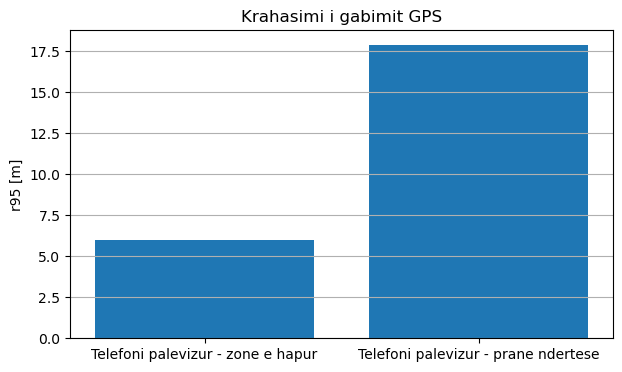

In [14]:
plt.figure(figsize=(7, 4))
plt.bar(comparison["Test"], comparison["r95 [m]"])
plt.ylabel("r95 [m]")
plt.title("Krahasimi i gabimit GPS")
plt.grid(axis="y")
plt.show()

## Gjatesia e ecjes

Ketu llogarisim gjatesine e rruges per testin e ecjes.

In [15]:
lat = np.deg2rad(walk["latitude"].to_numpy())
lon = np.deg2rad(walk["longitude"].to_numpy())

R = 6371000

dlat = np.diff(lat)
dlon = np.diff(lon)

lat_mid = (lat[:-1] + lat[1:]) / 2

dx = R * np.cos(lat_mid) * dlon
dy = R * dlat

step_distances = np.sqrt(dx**2 + dy**2)
total_distance = np.sum(step_distances)

print("Gjatesia e perafert e rruges [m]:", total_distance)

Gjatesia e perafert e rruges [m]: 526.2197983749885


## Trajektorja e ecjes

Ky grafik tregon rrugen e bere gjate ecjes.

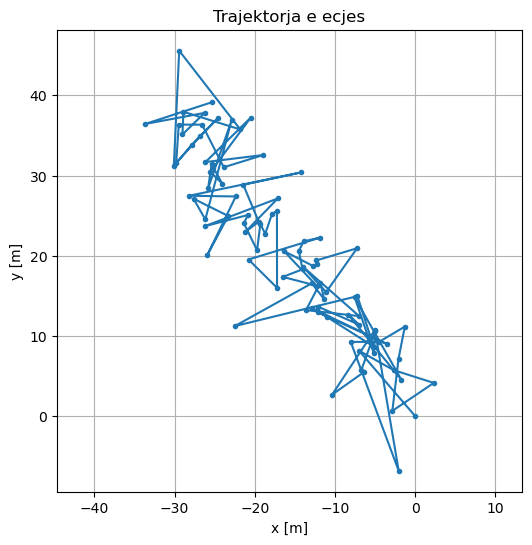

In [16]:
lat = np.deg2rad(walk["latitude"].to_numpy())
lon = np.deg2rad(walk["longitude"].to_numpy())

lat0 = lat[0]
lon0 = lon[0]

x_walk = R * np.cos(lat0) * (lon - lon0)
y_walk = R * (lat - lat0)

plt.figure(figsize=(6, 6))
plt.plot(x_walk, y_walk, marker="o", markersize=3)
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Trajektorja e ecjes")
plt.axis("equal")
plt.grid(True)
plt.show()

## Diskutim

Pozicioni GPS ndryshoi edhe kur telefoni ishte i palevizur.

Ne zonen e hapur, pikat ishin me afer njera-tjetres. Kjo tregon se sinjali GPS ishte me i mire.

Prane nderteses, gabimi ishte me i madh. Ndertesat mund te bllokojne ose reflektojne sinjalin GPS. Kjo e ben pozicionin me pak te sakte.

Vlera `r95` tregon rrezen ku ndodhen 95% e pikave GPS. Kur `r95` eshte me i madh, GPS eshte me pak i sakte.

Ne testin e ecjes, GPS tregoi drejtimin e pergjithshem te levizjes. Rruga nuk doli perfekt e drejte sepse GPS ka gjithmone gabim.

## Perfundim

Ne kete laborator studiuam saktesine e GPS ne tre raste: ne zone te hapur, prane nje ndertese dhe gjate ecjes.

Rezultatet tregojne se GPS ka gjithmone pak gabim. Ne zonen e hapur gabimi ishte me i vogel. Prane nderteses gabimi u rrit per shkak te bllokimit dhe reflektimit te sinjalit.

Gjate ecjes, GPS tregoi levizjen e pergjithshme, por me pak zhurme.

Pra, nje pike GPS nuk duhet marre si pozicion perfekt. Ajo eshte nje matje me pasiguri.